In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


In [2]:

# Load Tesla (TSLA) data again
tsla_data = yf.download('TSLA', start="2015-01-01", end="2024-10-31")
tsla_close = tsla_data['Close']

# Split data into training and testing sets
train_size = int(len(tsla_close) * 0.8)
train, test = tsla_close[:train_size], tsla_close[train_size:]


[*********************100%***********************]  1 of 1 completed


In [3]:

# Hyperparameter tuning using auto_arima
auto_model = auto_arima(train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print("Best ARIMA parameters (p, d, q):", auto_model.order)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=12345.046, Time=0.72 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12340.889, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=12339.852, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=12339.956, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=12339.337, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=12341.053, Time=0.28 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.261 seconds
Best ARIMA parameters (p, d, q): (0, 1, 0)


In [4]:

# Build and train the ARIMA model
model = ARIMA(train, order=auto_model.order)
arima_fit = model.fit()


/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [5]:

# Forecast
forecast = arima_fit.forecast(steps=len(test))

# Evaluation Metrics
mae = mean_absolute_error(test, forecast)
rmse = mean_squared_error(test, forecast, squared=False)
mape = mean_absolute_percentage_error(test, forecast)

# Print Evaluation Metrics
print(f"Evaluation Metrics for ARIMA Model:\nMAE: {mae}\nRMSE: {rmse}\nMAPE: {mape}")


Evaluation Metrics for ARIMA Model:
MAE: 38.907052519827175
RMSE: 49.1129918969654
MAPE: 0.17612209105913845


/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


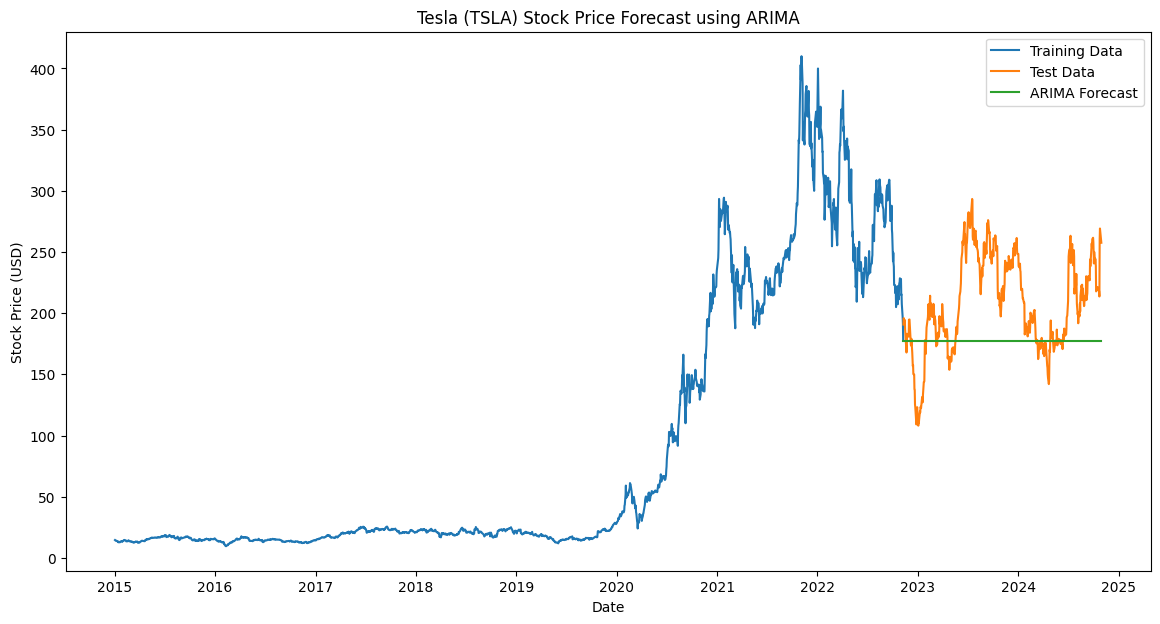

In [6]:

# Plotting the forecast vs. actuals
plt.figure(figsize=(14, 7))
plt.plot(train, label="Training Data")
plt.plot(test, label="Test Data")
plt.plot(test.index, forecast, label="ARIMA Forecast")
plt.legend()
plt.title("Tesla (TSLA) Stock Price Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.show()
